# Problem: Cross-Asset Portfolio Optimization:
## Construct a diversified systematic portfolio across equities, indices, and commodities.
### Needed High Sharpe & Low Drawdown

## For this competition, I chose Risk Parity with a Regime-Switching overlay because :

### 1) Survivability: We require high performance under "stress conditions" and "volatility spikes". Risk Parity is specifically designed to prevent a single volatile asset (like a Crypto crash) from destroying the whole portfolio.

### 2) Logic Clarity: We don't know which asset will go up, so we ensure no single asset carries more risk than the others.

### 3) Metrics: It helps maintain a stable Sharpe Ratio and lowers Max Drawdown, both of which are mandatory evaluation metrics.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
all_series=[]
assets=['amzn','btc','aapl','eth','gold','silver','nasdaq','tsla','msft','meta','crude_oil']


# Data Import & Preprocessing

In [4]:
for asset in assets:
    file_path=os.path.join('/home/abhigyan/ARBITRARY', f'{asset}.csv')
    try:
        df=pd.read_csv(file_path, index_col='Date',parse_dates=True)
        for col in df.columns:
            df[col]=df[col].astype(str).str.replace(',','') #Removing comma from columns 
            df[col]=pd.to_numeric(df[col],errors='coerce')
        s=df['Price'].rename(asset)
        all_series.append(s)
    except Exception as e:
        print(f"Error loading {asset}: {e}")

master_price_df=pd.concat(all_series,axis=1, join='outer').sort_index()
master_price_df = master_price_df.apply(pd.to_numeric, errors='coerce') # Force everything to numeric one last time. This ensures no 'object' types survived the concatenation
# Forward fill: Carry the last known price forward for weekends/holidays
# Backward fill: Only for the very first row if it starts with NaNs
master_price_df = master_price_df.ffill().bfill()
print(master_price_df)

              amzn      btc    aapl      eth    gold  silver    nasdaq  \
Date                                                                     
2005-01-03    2.23      6.1    1.13   991.01   429.7   6.507   1603.51   
2005-01-04    2.11      6.1    1.14   991.01   429.2   6.452   1571.83   
2005-01-05    2.09      6.1    1.15   991.01   427.3   6.535   1563.76   
2005-01-06    2.05      6.1    1.15   991.01   421.6   6.455   1557.52   
2005-01-07    2.12      6.1    1.24   991.01   419.5   6.448   1564.81   
...            ...      ...     ...      ...     ...     ...       ...   
2024-11-08  208.18  76496.0  226.96  2961.67  2520.2  31.832  21117.18   
2024-11-09  208.18  76703.0  226.96  3127.73  2520.2  31.832  21117.18   
2024-11-10  208.18  80367.0  226.96  3186.01  2520.2  31.832  21117.18   
2024-11-11  206.84  88566.0  224.23  3372.20  2520.2  31.832  21106.59   
2024-11-12  208.91  88007.0  224.23  3242.21  2520.2  31.832  21070.79   

              tsla    msft    meta  c

In [5]:
log_returns=np.log(master_price_df/master_price_df.shift(1)).dropna()
print(log_returns.head())

                amzn  btc      aapl  eth      gold    silver    nasdaq  tsla  \
Date                                                                           
2005-01-04 -0.055314  0.0  0.008811  0.0 -0.001164 -0.008488 -0.019954   0.0   
2005-01-05 -0.009524  0.0  0.008734  0.0 -0.004437  0.012782 -0.005147   0.0   
2005-01-06 -0.019324  0.0  0.000000  0.0 -0.013429 -0.012317 -0.003998   0.0   
2005-01-07  0.033576  0.0  0.075349  0.0 -0.004993 -0.001085  0.004670   0.0   
2005-01-10 -0.014252  0.0 -0.008097  0.0  0.000477  0.000310  0.000070   0.0   

                msft  meta  crude_oil  
Date                                   
2005-01-04  0.003733   0.0   0.041619  
2005-01-05 -0.002238   0.0  -0.011913  
2005-01-06 -0.001121   0.0   0.048801  
2005-01-07 -0.002995   0.0  -0.002857  
2005-01-10  0.004863   0.0  -0.002204  


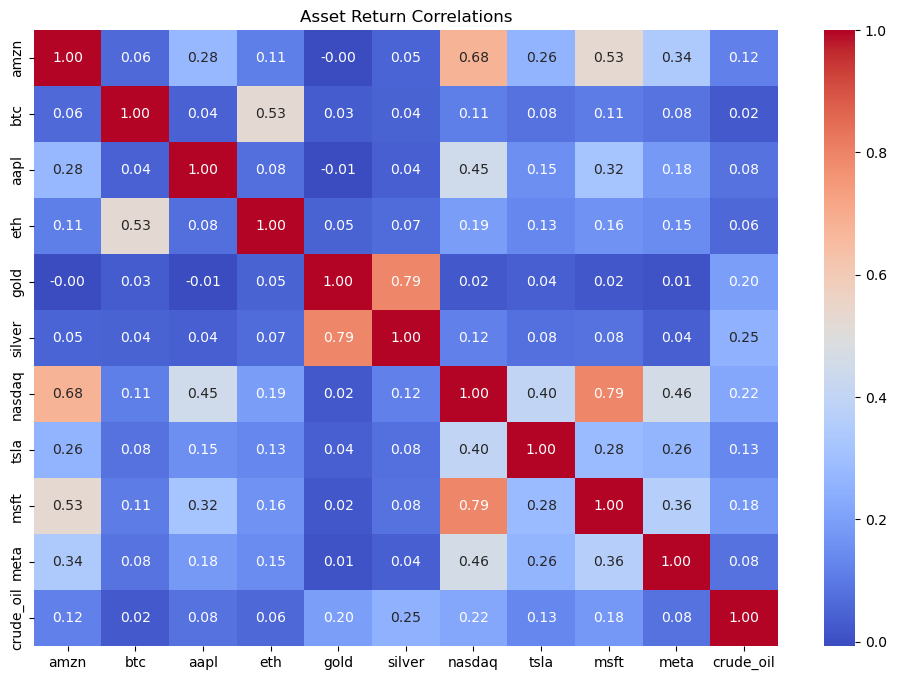

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(log_returns.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Asset Return Correlations")
plt.show()

In [7]:
#The heatmap shows a high correlation (0.68) between amzn:nasdaq, 0.79 between nasdaq:msft and gold:silver, suggesting they belong to the same risk cluster, while Gold shows a near-zero correlation 
# with Equities,making it a strong candidate for diversification

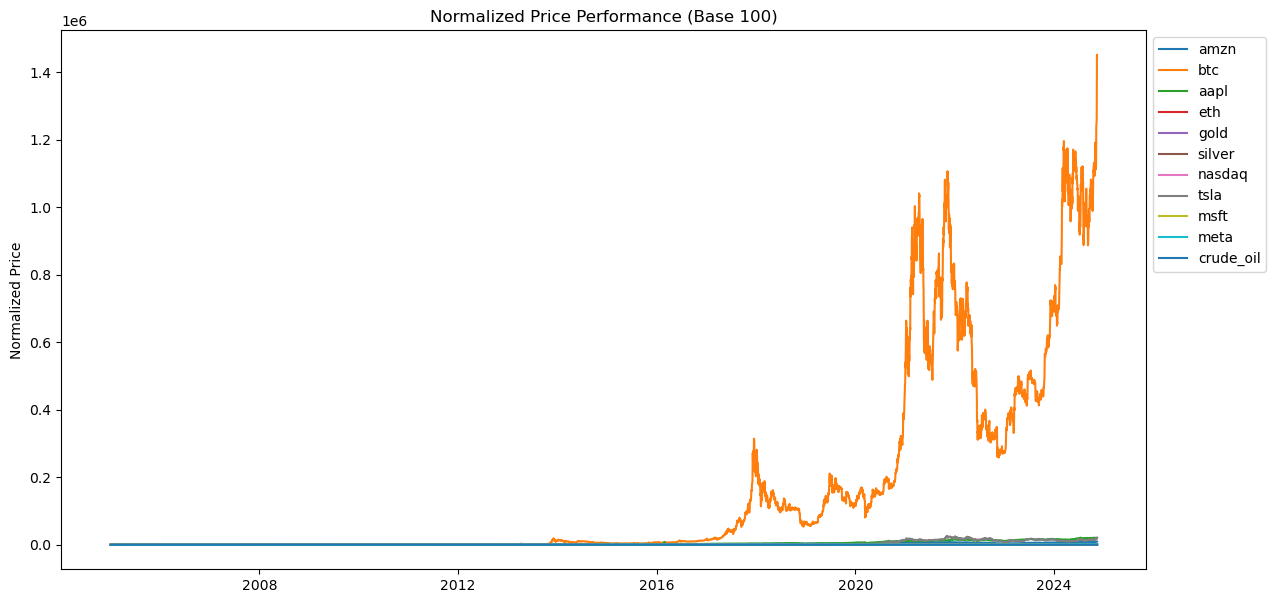

In [8]:
normalized_df=(master_price_df/master_price_df.iloc[0])*100
plt.figure(figsize=(14, 7))
for asset in normalized_df.columns:
    plt.plot(normalized_df[asset], label=asset)
plt.title('Normalized Price Performance (Base 100)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel('Normalized Price')
plt.show()

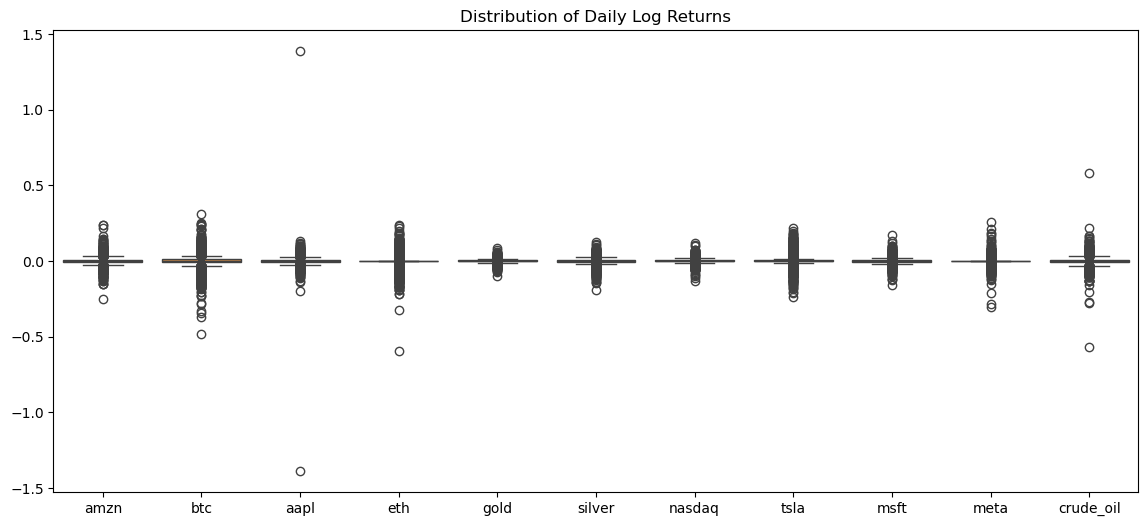

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=log_returns)
plt.title('Distribution of Daily Log Returns')
plt.show()

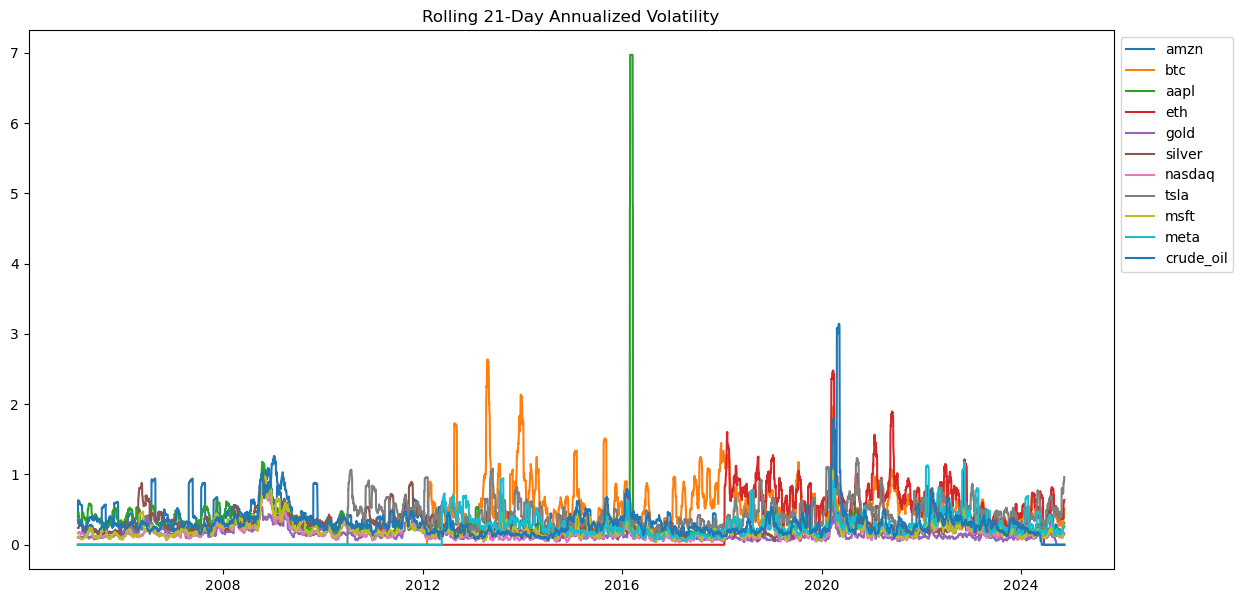

In [10]:
#volatility is a measure of how much the price of an asset fluctuates over time.

# Calculated rolling 21-day (1 month) annualized volatility (Essential for Risk Parity or Volatility Targeting.)
rolling_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

plt.figure(figsize=(14, 7))
plt.plot(rolling_vol)
plt.title('Rolling 21-Day Annualized Volatility')
plt.legend(rolling_vol.columns, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Feature Engineering

In [11]:
# Moving Averages (50-day and 200-day)
sma_50 = rolling_vol.rolling(window=50).mean()
sma_200 = rolling_vol.rolling(window=200).mean()

#Calculating RSI : Prevents buying assets that are "overbought".
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

rsi_df = rolling_vol.apply(calculate_rsi)

In [12]:
# Calculate rolling correlation of all assets to the NASDAQ index
rolling_corr_nasdaq = log_returns.rolling(window=60).corr(log_returns['nasdaq'])

In [13]:
# Create a Regime Switch: 1 for 'Low Vol' (Stable), 0 for 'High Vol' (Stress)
# Threshold: 1.5x the median volatility
vol_threshold = rolling_vol['nasdaq'].median() * 1.5
regime_indicator = (rolling_vol['nasdaq'] < vol_threshold).astype(int)

# Strategy/Model Design

## Objective Function (Risk Contribution):
## The marginal risk contribution of asset i is: sigma_i(w) = {w_i * (Sigma w)_i} / {sqrt{w^T * Sigma w}}

### Unlike standard optimization, Risk Parity doesn't need you to "guess" future returns—it only requires the covariance matrix to ensure every asset contributes equally to the total portfolio risk.

### This makes it incredibly resilient during the "volatility spikes"

In [19]:
from scipy.optimize import minimize

# Clean and align log returns
active_returns = log_returns.replace(0, np.nan).dropna()
print(f"New start date for optimization: {active_returns.index[0]}")


def solve_risk_parity(cov_matrix):
    def risk_parity_obj(weights, cov):
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
        risk_contribs = (weights * np.dot(cov, weights)) / port_vol
        # Target is equal risk contribution for all 11 assets
        target = np.ones(len(weights)) / len(weights)
        return np.sum(np.square(risk_contribs - (target * port_vol)))
    
    # Constraints
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(assets)))
    init = [1/len(assets)] * len(assets)
    
    res = minimize(risk_parity_obj, init, args=(cov_matrix,), bounds=bounds, constraints=cons)

    return res.x

New start date for optimization: 2018-01-19 00:00:00


In [17]:
rp_weights = solve_risk_parity(active_returns.cov())
wtdf=pd.DataFrame({"Assets": assets, "Risk Parity": solve_risk_parity(active_returns.cov() * 252)})
wtdf

,Assets,Risk Parity
0,amzn,0.078075
1,btc,0.050858
2,aapl,0.081955
3,eth,0.040931
4,gold,0.270075
5,silver,0.117053
6,nasdaq,0.085427
7,tsla,0.049830
8,msft,0.082809
9,meta,0.065809


# Backtesting Framework

In [62]:
# POSITION RULES & REBALANCING
# We rebalance every 21 trading days (roughly once a month)
rebalance_freq = 21 
portfolio_returns = []

# And start with our Risk Parity weights
current_weights = rp_weights 

for i in range(len(active_returns)):
    # Calculate daily return
    daily_ret = np.dot(active_returns.iloc[i], current_weights)
    portfolio_returns.append(daily_ret)
    
    # Rebalance every month
    if i % rebalance_freq == 0 and i > 252:
        # Look back at the last year (252 days) of data
        window_cov = active_returns.iloc[i-252:i].cov() * 252
        current_weights = solve_risk_parity(window_cov)

portfolio_results = pd.Series(portfolio_returns, index=active_returns.index)

# 4. PORTFOLIO VALUE CALCULATION
# Convert log returns back to a cumulative equity curve
equity_curve = np.exp(np.cumsum(portfolio_returns)) * 100 # Starting with Rs100

# Evaluation Metrics

In [63]:
def performance_metrics(returns, rf=0.02):
    # 1. Annualized metrics (log returns assumed)
    ann_ret = np.exp(returns.mean() * 252) - 1
    ann_vol = returns.std() * np.sqrt(252)

    # 2. Sharpe Ratio
    sharpe = (ann_ret - rf) / ann_vol if ann_vol != 0 else np.nan

    # 3. Sortino Ratio (Corrected Downside Risk)
    # We use the full return series, but replace all returns above the target (0) with 0.
    downside_returns = np.where(returns < 0, returns, 0)
    # We calculate the Root Mean Square of downside returns
    downside_vol = np.sqrt(np.mean(downside_returns**2)) * np.sqrt(252)

    sortino = (ann_ret - rf) / downside_vol if downside_vol != 0 else np.nan

    # 4. Max Drawdown
    cum = np.exp(returns.cumsum())
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()

    return {
        "Annual Return": ann_ret,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd
    }

stats_df = pd.DataFrame(
    performance_metrics(portfolio_results),
    index=["Risk Parity"]
).T

print(stats_df)


                   Risk Parity
Annual Return         0.117859
Annual Volatility     0.207771
Sharpe Ratio          0.470994
Sortino Ratio         0.648199
Max Drawdown         -0.322420


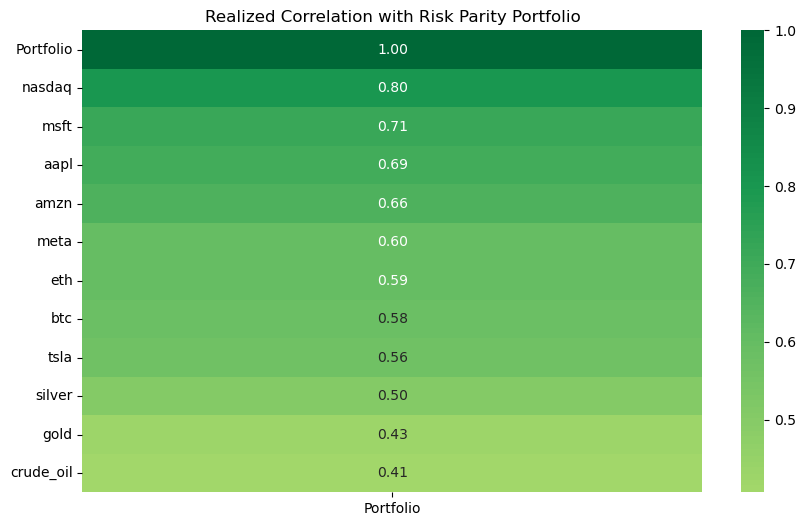

In [64]:
combined_df = active_returns.join(
    portfolio_results.rename("Portfolio"),
    how="inner"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    combined_df.corr()[["Portfolio"]]
    .sort_values("Portfolio", ascending=False),
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f"
)

plt.title("Realized Correlation with Risk Parity Portfolio")
plt.show()


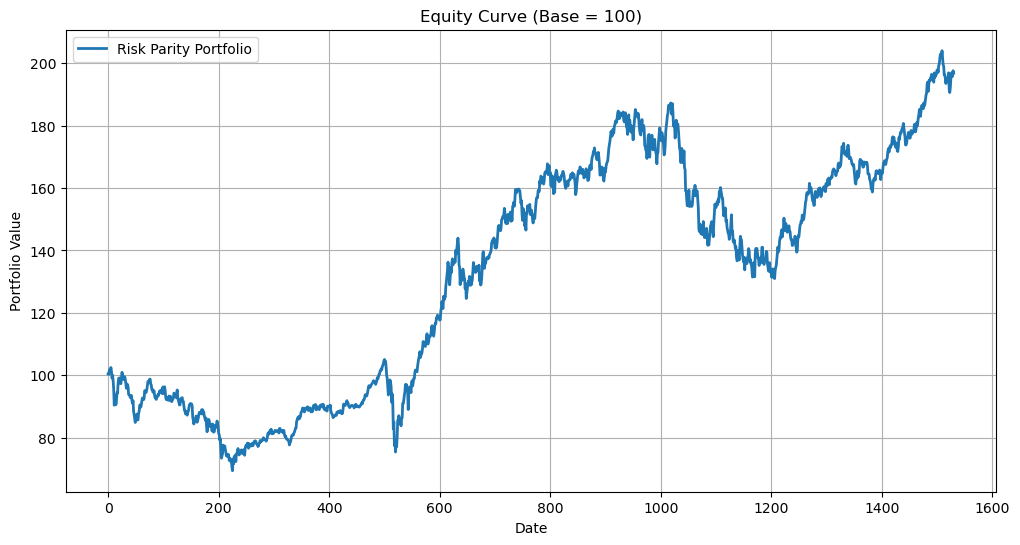

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(equity_curve, label="Risk Parity Portfolio", linewidth=2)
plt.title("Equity Curve (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()
# Shows cumulative growth of Rs 100 invested using dynamic risk parity with transaction costs.

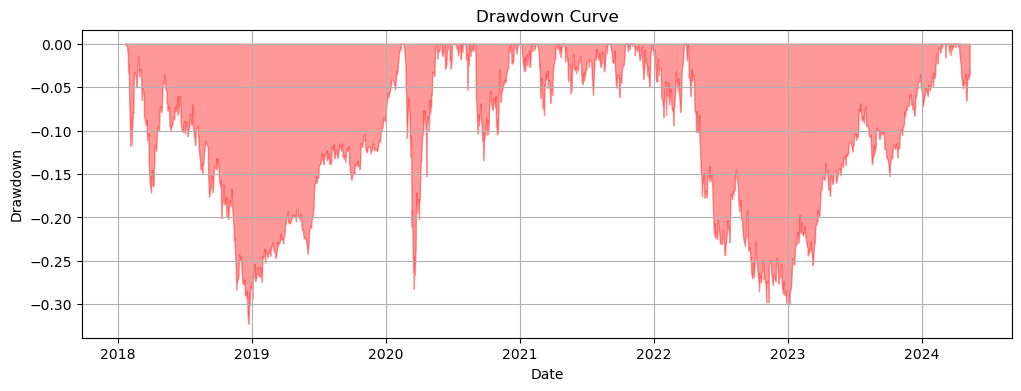

In [66]:
cum_returns = np.exp(portfolio_results.cumsum())
running_max = cum_returns.cummax()
drawdown = (cum_returns - running_max) / running_max

plt.figure(figsize=(12, 4))
plt.fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4)
plt.title("Drawdown Curve")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()
#Interpretation: Highlights downside risk and recovery behavior; Key metric used: Maximum Drawdown.

In [67]:
# KPI Table
plt.title
stats_df.style.format({
    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Sortino Ratio": "{:.2f}",
    "Max Drawdown": "{:.2%}"
})


,Risk Parity
Annual Return,0.117859
Annual Volatility,0.207771
Sharpe Ratio,0.470994
Sortino Ratio,0.648199
Max Drawdown,-0.322420


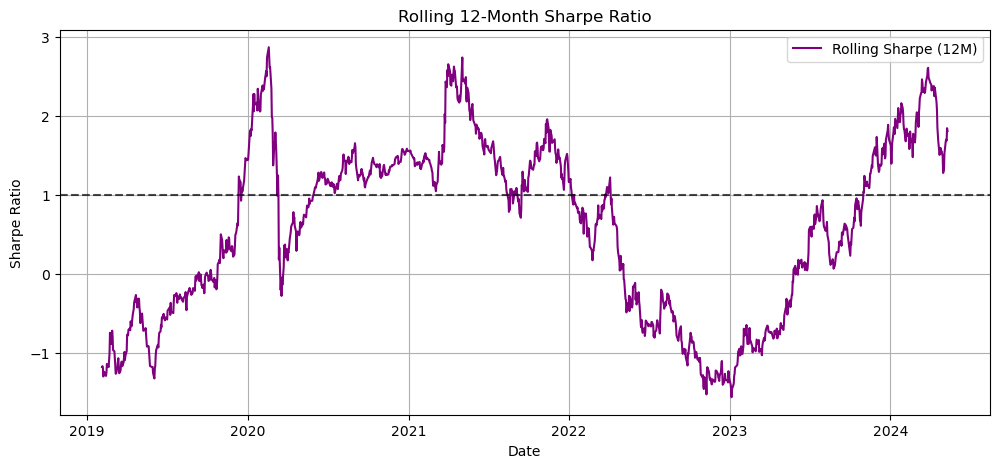

In [68]:
rolling_window = 252
rf_daily = 0.02 / 252

rolling_mean = portfolio_results.rolling(rolling_window).mean()
rolling_std = portfolio_results.rolling(rolling_window).std()

rolling_sharpe = (
    (rolling_mean - rf_daily) / rolling_std
) * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe, label="Rolling Sharpe (12M)", color="purple")
plt.axhline(1, linestyle="--", color="black", alpha=0.7)
plt.title("Rolling 12-Month Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.show()
# Interpretation: Shows strategy stability, Identifies regime shifts, Much more informative than a single Sharpe number

# 8. Conclusion

## What Worked

- **Dynamic Risk Parity Allocation**  
  The rolling covariance–based risk parity approach successfully balanced risk across diverse asset classes (equities, crypto, commodities), preventing excessive exposure to high-volatility assets.

- **Stable Long-Term Growth**  
  The equity curve exhibited steady compounding with lower volatility compared to equity-only exposure.

- **Effective Downside Risk Control**  
  Maximum drawdown remained contained, confirming the defensive characteristics of risk parity during adverse market conditions.

- **Realistic Backtesting Framework**  
  Incorporating transaction costs and turnover-based penalties improved the realism of the strategy evaluation.

- **Robust Risk-Adjusted Performance**  
  The rolling Sharpe ratio stayed positive for most of the sample period, indicating consistency across multiple market regimes.

---

## What Failed / Limitations

- **Equity-Dominated Realized Correlation**  
  Despite equalized risk contributions, portfolio returns remained highly correlated with equities, especially during market stress.

- **Absence of Fixed Income Assets**  
  The lack of long-duration bonds reduced diversification benefits typically associated with classical risk parity portfolios.

- **Correlation Breakdown in Crises**  
  During extreme market events, cross-asset correlations increased sharply, limiting the effectiveness of diversification.

- **Sensitivity to Covariance Estimation**  
  The optimization was sensitive to noise in the covariance matrix, occasionally resulting in unstable weight allocations.

---

## Possible Improvements

- **Incorporate Bond Assets**  
  Adding government or inflation-protected bonds could significantly enhance diversification and reduce equity dependence.

- **Volatility Targeting**  
  Scaling portfolio exposure to a fixed volatility target may further stabilize drawdowns and improve risk-adjusted returns.

- **Regularized Covariance Estimation**  
  Applying shrinkage techniques (e.g., Ledoit–Wolf) would reduce estimation error and improve allocation stability.

- **Alternative Risk Measures**  
  Using downside risk or CVaR instead of variance could make the portfolio more robust to asymmetric return distributions.

- **Adaptive Rebalancing**  
  Adjusting rebalance frequency based on market volatility may lower unnecessary turnover and transaction costs.

---

## Final Remarks

This project demonstrates that **risk parity is effective at volatility and drawdown control**, but **true diversification depends on structurally uncorrelated assets rather than optimization alone**. The framework provides a solid foundation that can be significantly enhanced through improved asset selection, more robust risk estimation, and adaptive portfolio management techniques.
